In [ ]:
import pandas as pd
from datetime import datetime
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
from src.routing.route_utils import travel_time_minutes, compute_route_schedule, route_feasibility, route_duration
data_path = Path("../data/features/olist/delivery_jobs_dataset.csv")

In [2]:
delivery_df = pd.read_csv(
    data_path,
    parse_dates = [
        'ready_time',
        'due_date'
    ]
)

delivery_df.head()

,job_id,order_id,seller_id,customer_id,pickup_lat,pickup_lng,delivery_lat,delivery_lng,ready_time,due_date,service_time_min,demand
0,e481f51cbdc54678b7cc49136f2d6af7,e481f51cbdc54678b7cc49136f2d6af7,3504c0cb71d7fa48d967e0e4c94d59d9,9ef432eb6251297304e76186b10a928d,-23.680729,-46.444238,-23.576983,-46.587161,2017-10-02 11:07:15,2017-10-18,30,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,53cdb2fc8bc7dce0b6741e2150273451,289cdb325fb7e7f891c38608bf9e0962,b0830fb4747a6c6d20dea0b8c802d7ef,-19.807681,-43.980427,-12.177924,-44.660711,2018-07-26 03:24:27,2018-08-13,30,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,47770eb9100c2d0c44946d9cf07ec65d,4869f7a5dfa277a7dca6462dcf3b52b2,41ce2a54c0b03bf3443c3d931a367089,-21.363502,-48.229601,-16.745150,-48.514783,2018-08-08 08:55:23,2018-09-04,30,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,949d5b44dbf5de918fe9c16f97b45f8a,66922902710d126a0e7d26b0e3805106,f88197465ea7920adcdbec7375364d82,-19.837682,-43.924053,-5.774190,-35.271143,2017-11-18 19:45:59,2017-12-15,30,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,ad21c59c0840e6cb83a9ceb5573f8159,2c9e548be18521d1c43cde1c582c6de8,8ab97904e6daea8866dbdbc4fb7aad2c,-23.543395,-46.262086,-23.676370,-46.514627,2018-02-13 22:20:29,2018-02-26,30,1.0


In [3]:
# time-window durations in minutes
tw = (delivery_df['due_date'] - delivery_df['ready_time']).dt.total_seconds() / 60
tw.describe()

count     98797.000000
mean      33609.087532
std       12709.697061
min     -209717.633333
25%       25863.350000
50%       32737.550000
75%       40463.633333
max      221149.483333
dtype: float64

In [4]:
sample_df = delivery_df.sample(10, random_state = 7).copy()

# Sort by ready_time to simulate natural arrival
sample_df = (
    sample_df
    .sort_values(by='ready_time')
    .reset_index(drop=True)
)

sample_df

,job_id,order_id,seller_id,customer_id,pickup_lat,pickup_lng,delivery_lat,delivery_lng,ready_time,due_date,service_time_min,demand
0,23289a87ad267a113c014020edf79ea2,23289a87ad267a113c014020edf79ea2,4c03b9dd4c11ee2cb35c96c49efc9420,d7f5c766748d1e31c16f498e25bfa6f3,-23.211746,-46.762875,-20.892832,-47.585040,2017-07-06 10:23:41,2017-07-26,30,1.0
1,d09e3fd9caced8c85a2db6da7c0fbcdd,d09e3fd9caced8c85a2db6da7c0fbcdd,d98eec89afa3380e14463da2aabaea72,3efba37b349cdd2c2d8871234011eaa6,-30.033213,-51.231438,-23.621390,-46.615974,2017-07-19 03:50:39,2017-08-10,30,1.0
2,da779b6680b82d9dc38f900be7380323,da779b6680b82d9dc38f900be7380323,6560211a19b47992c3666cc44a7e94c0,7175c3ddc838d1b8c05b7b6db00116cb,-23.652366,-46.755753,-9.431110,-38.217443,2017-07-23 18:50:21,2017-08-23,30,1.0
3,3ebbf40c93199bd38c2b821855ab1800,3ebbf40c93199bd38c2b821855ab1800,b499c00f28f4b7069ff6550af8c1348a,6249709637eaa28557e42c0197951cb1,-22.600004,-47.407129,-22.914255,-47.038841,2018-01-25 02:58:11,2018-02-08,30,1.0
4,491796bba785a397014b993ef8006380,491796bba785a397014b993ef8006380,53e4c6e0f4312d4d2107a8c9cddf45cd,7ec2fa9e2ebba90c99f413e7b8c5f3cd,-22.740325,-46.896754,-7.562445,-34.999375,2018-01-26 12:21:39,2018-03-12,30,1.0
5,5713bef560364e39ec1630ff62449492,5713bef560364e39ec1630ff62449492,16090f2ca825584b5a147ab24aa30c86,793864114259d54262b38703f165acd2,-23.114731,-46.552881,-21.792839,-46.567365,2018-02-20 07:15:29,2018-03-13,30,1.0
6,3449aa90c200ac98335249ce9f0e3151,3449aa90c200ac98335249ce9f0e3151,5a05a16bb50629ee31afab8a6d4c2674,672fd46db2cd92beb42ce95dded37e49,-29.178216,-51.148684,-29.999230,-53.500549,2018-04-04 03:10:22,2018-04-19,30,1.0
7,82121ebedf0f27bfb35630958489c7ea,82121ebedf0f27bfb35630958489c7ea,fa1c13f2614d7b5c4749cbc52fecda94,d0296a9161a79996162a6a4f0835ed2d,-22.822137,-47.270335,-23.561190,-46.474486,2018-06-25 17:19:17,2018-07-05,30,1.0
8,5b55ee8a50b508709962ccc9eba0de7f,5b55ee8a50b508709962ccc9eba0de7f,6560211a19b47992c3666cc44a7e94c0,eb18708944fc7cd5c0eb37c6e34944e7,-23.652366,-46.755753,-22.922381,-43.629511,2018-07-19 10:25:18,2018-08-16,30,1.0
9,7563e13fcf7f6c6d8db57ef0c5760c87,7563e13fcf7f6c6d8db57ef0c5760c87,9c1c0c36cd23c20897e473901a8fb149,ea523606564418ccc7fa53b7a081c510,-24.014395,-46.438358,-23.561434,-46.689846,2018-07-30 15:24:44,2018-08-02,30,2.0


In [5]:
# converting samples to route list
route = sample_df.to_dict('records')
route[0:2]

[{'job_id': '23289a87ad267a113c014020edf79ea2',
  'order_id': '23289a87ad267a113c014020edf79ea2',
  'seller_id': '4c03b9dd4c11ee2cb35c96c49efc9420',
  'customer_id': 'd7f5c766748d1e31c16f498e25bfa6f3',
  'pickup_lat': -23.211746332732215,
  'pickup_lng': -46.762875138051314,
  'delivery_lat': -20.892832077005902,
  'delivery_lng': -47.585039751459725,
  'ready_time': Timestamp('2017-07-06 10:23:41'),
  'due_date': Timestamp('2017-07-26 00:00:00'),
  'service_time_min': 30,
  'demand': 1.0},
 {'job_id': 'd09e3fd9caced8c85a2db6da7c0fbcdd',
  'order_id': 'd09e3fd9caced8c85a2db6da7c0fbcdd',
  'seller_id': 'd98eec89afa3380e14463da2aabaea72',
  'customer_id': '3efba37b349cdd2c2d8871234011eaa6',
  'pickup_lat': -30.033212764480137,
  'pickup_lng': -51.23143789959834,
  'delivery_lat': -23.621390480559317,
  'delivery_lng': -46.61597395073291,
  'ready_time': Timestamp('2017-07-19 03:50:39'),
  'due_date': Timestamp('2017-08-10 00:00:00'),
  'service_time_min': 30,
  'demand': 1.0}]

In [6]:
# defining route start time -> start at first job's ready time
start_time = route[0]['ready_time']
start_time

Timestamp('2017-07-06 10:23:41')

In [7]:
# Computing schedule
feasible, schedule = compute_route_schedule(route, start_time)
print(f"Feasible: {feasible}")

display(pd.DataFrame(schedule))

# Route duration
duration = route_duration(route, start_time)
print(f"Route duration in mins: {duration}")

Feasible: True


,job_id,arrival_time,departure_time
0,23289a87ad267a113c014020edf79ea2,2017-07-06 10:23:41.000000000,2017-07-06 10:53:41.000000000
1,d09e3fd9caced8c85a2db6da7c0fbcdd,2017-07-30 12:34:19.251676491,2017-07-30 13:04:19.251676491
2,da779b6680b82d9dc38f900be7380323,2017-08-13 05:10:58.919891137,2017-08-13 05:40:58.919891137
3,3ebbf40c93199bd38c2b821855ab1800,2018-01-25 02:58:11.000000000,2018-01-25 03:28:11.000000000
4,491796bba785a397014b993ef8006380,2018-02-18 10:02:56.252753350,2018-02-18 10:32:56.252753350
5,5713bef560364e39ec1630ff62449492,2018-03-04 02:52:52.638664913,2018-03-04 03:22:52.638664913
6,3449aa90c200ac98335249ce9f0e3151,2018-04-04 03:10:22.000000000,2018-04-04 03:40:22.000000000
7,82121ebedf0f27bfb35630958489c7ea,2018-06-25 17:19:17.000000000,2018-06-25 17:49:17.000000000
8,5b55ee8a50b508709962ccc9eba0de7f,2018-07-19 10:25:18.000000000,2018-07-19 10:55:18.000000000
9,7563e13fcf7f6c6d8db57ef0c5760c87,2018-07-30 15:24:44.000000000,2018-07-30 15:54:44.000000000


Route duration in mins: 560491.05


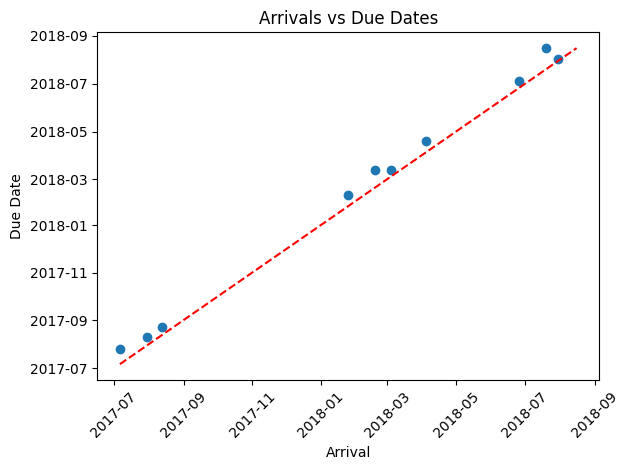

In [18]:
# visualizing Arrivals vs. Due Dates
schedule_df = pd.DataFrame(schedule)

merged = sample_df.merge(schedule_df, on = 'job_id')

plt.figure()
plt.scatter(
    merged['arrival_time'],
    merged['due_date']
)

# reference line
min_time = min(
    merged['arrival_time'].min(),
    merged['due_date'].min()
)

max_time = max(
    merged['arrival_time'].max(),
    merged['due_date'].max()
)

plt.plot(
    [min_time, max_time],
    [min_time, max_time],
    linestyle = '--',
    color = 'red'
)

plt.xlabel('Arrival')
plt.ylabel('Due Date')
plt.title('Arrivals vs Due Dates')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()